# 08. Extended Analysis

**Содержание:**
1. **Cascade threshold ablation** — обоснование выбора порогов 0.30/0.70
2. **Heatmap generator × domain** — слабые места по генераторам и доменам
3. **Adversarial v2** — гомоглифы + back-translation
4. **Segment-level scoring** — PoC анализа по окнам
5. **Две кривые деградации** — TF-IDF vs Transformer на edited AI

In [ ]:
import json
import sys
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from scipy.sparse import hstack

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "data_collection"))

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

SEED = 42
np.random.seed(SEED)

def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]

## 0. Загрузка данных и моделей

In [2]:
# Training data
train_tm = load_jsonl(PROJECT_ROOT / "data/splits/train_tm.jsonl")
val_tm = load_jsonl(PROJECT_ROOT / "data/splits/val_tm.jsonl")
test_tm = load_jsonl(PROJECT_ROOT / "data/splits/test_tm.jsonl")
holdout_tm = load_jsonl(PROJECT_ROOT / "data/splits/holdout_tm_unseen.jsonl")

print(f"Train: {len(train_tm)}, Val: {len(val_tm)}, Test: {len(test_tm)}, Holdout: {len(holdout_tm)}")

Train: 9000, Val: 1200, Test: 2311, Holdout: 12000


In [3]:
# Edited AI
edited_dir = PROJECT_ROOT / "data/edited_ai"
edited_data = {}
for f in sorted(edited_dir.glob("edited_*.jsonl")):
    rows = load_jsonl(f)
    if rows:
        level = rows[0].get("meta", {}).get("edit_level", f.stem)
        edited_data[level] = rows
        print(f"{level:15s}: {len(rows)} texts")

heavy_edit     : 150 texts
light_edit     : 150 texts
mixed          : 150 texts
replace_10     : 100 texts
replace_30     : 100 texts
replace_50     : 100 texts


In [4]:
# Обучение Baseline C (TF-IDF topic-matched)
all_train = train_tm + val_tm
train_texts = [r["text"] for r in all_train]
train_labels = [r["label"] if isinstance(r["label"], int) else (1 if r["label"] == "ai" else 0) for r in all_train]

tfidf_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=50000, sublinear_tf=True)
tfidf_word = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), max_features=50000, sublinear_tf=True)

X_char = tfidf_char.fit_transform(train_texts)
X_word = tfidf_word.fit_transform(train_texts)
X_train = hstack([X_char, X_word])

logreg = LogisticRegression(C=50.0, max_iter=1000, random_state=SEED, solver="liblinear")
logreg.fit(X_train, train_labels)

def tfidf_predict_proba(texts):
    X = hstack([tfidf_char.transform(texts), tfidf_word.transform(texts)])
    return logreg.predict_proba(X)[:, 1]

print(f"Baseline C trained: {X_train.shape}")

Baseline C trained: (10200, 100000)


In [5]:
# Загрузка Transformer
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = str(PROJECT_ROOT / "artifacts/transformer/model")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
trans_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
trans_model.eval()

def transformer_predict_proba(texts, batch_size=16):
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                          max_length=512, padding=True).to(device)
        with torch.no_grad():
            probs = torch.softmax(trans_model(**inputs).logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)

print(f"Transformer loaded on {device}")

C:\Users\vlad_\Project__\ai-text-trust-service\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 12565.55it/s]

Transformer loaded on cuda


In [6]:
# Загрузка cached predictions (Transformer)
cached = json.load(open(PROJECT_ROOT / "artifacts/transformer/cached_predictions.json"))
print(f"Cached keys: {list(cached.keys())}")
for k, v in cached.items():
    print(f"  {k}: {len(v['probs'])} texts")

Cached keys: ['test_tm', 'holdout_tm', 'adversarial']
  test_tm: 1800 texts
  holdout_tm: 12000 texts
  adversarial: 511 texts


In [7]:
# Получаем TF-IDF и Transformer probs для test_tm и holdout_tm
# ВАЖНО: cached predictions содержат 1800 текстов (test_tm без adversarial)
# и 511 adversarial отдельно. test_tm.jsonl содержит 2311 = 1800 + 511.

# Разделяем test_tm на clean (1800) и adversarial (511)
test_clean = [r for r in test_tm if r.get("source_model", "") != "adversarial" and "adversarial" not in r.get("source_name", "")]
test_adv = [r for r in test_tm if r.get("source_model", "") == "adversarial" or "adversarial" in r.get("source_name", "")]

print(f"test_tm: {len(test_tm)} total = {len(test_clean)} clean + {len(test_adv)} adversarial")

# TF-IDF probs — пересчитываем
test_clean_texts = [r["text"] for r in test_clean]
test_clean_labels = np.array([r["label"] if isinstance(r["label"], int) else (1 if r["label"] == "ai" else 0) for r in test_clean])
tfidf_probs_test = tfidf_predict_proba(test_clean_texts)

holdout_texts = [r["text"] for r in holdout_tm]
holdout_labels = np.array([r["label"] if isinstance(r["label"], int) else (1 if r["label"] == "ai" else 0) for r in holdout_tm])
tfidf_probs_holdout = tfidf_predict_proba(holdout_texts)

# Adversarial — TF-IDF
adv_texts = [r["text"] for r in test_adv]
tfidf_probs_adv = tfidf_predict_proba(adv_texts)

# Transformer — из кэша
trans_probs_test = np.array(cached["test_tm"]["probs"])
trans_probs_holdout = np.array(cached["holdout_tm"]["probs"])
trans_probs_adv = np.array(cached["adversarial"]["probs"])

print(f"Test clean: TF-IDF={len(tfidf_probs_test)}, Transformer={len(trans_probs_test)}")
print(f"Holdout: TF-IDF={len(tfidf_probs_holdout)}, Transformer={len(trans_probs_holdout)}")
print(f"Adversarial: TF-IDF={len(tfidf_probs_adv)}, Transformer={len(trans_probs_adv)}")

assert len(tfidf_probs_test) == len(trans_probs_test), f"Size mismatch test: {len(tfidf_probs_test)} vs {len(trans_probs_test)}"
assert len(tfidf_probs_holdout) == len(trans_probs_holdout), f"Size mismatch holdout!"
assert len(tfidf_probs_adv) == len(trans_probs_adv), f"Size mismatch adversarial!"
print("All sizes match ✓")

test_tm: 2311 total = 1800 clean + 511 adversarial


Test clean: TF-IDF=1800, Transformer=1800
Holdout: TF-IDF=12000, Transformer=12000
Adversarial: TF-IDF=511, Transformer=511
All sizes match ✓


In [8]:
def cascade_ablation(tfidf_probs, trans_probs, labels, lo, hi):
    """Симуляция cascade с заданными порогами."""
    final_probs = tfidf_probs.copy()
    uncertain = (tfidf_probs >= lo) & (tfidf_probs <= hi)
    final_probs[uncertain] = trans_probs[uncertain]
    
    preds = (final_probs >= 0.5).astype(int)
    f1 = f1_score(labels, preds, average="macro")
    pct_transformer = uncertain.mean() * 100
    
    return f1, pct_transformer, final_probs

# Пары порогов + крайние точки
THRESHOLD_PAIRS = [
    (0.0, 0.0, "TF-IDF only"),
    (0.45, 0.55, "0.45/0.55"),
    (0.40, 0.60, "0.40/0.60"),
    (0.35, 0.65, "0.35/0.65"),
    (0.30, 0.70, "0.30/0.70"),
    (0.25, 0.75, "0.25/0.75"),
    (0.20, 0.80, "0.20/0.80"),
    (0.0, 1.0, "Transformer only"),
]

ablation_results = []

for lo, hi, name in THRESHOLD_PAIRS:
    f1_test, pct_test, _ = cascade_ablation(tfidf_probs_test, trans_probs_test, test_clean_labels, lo, hi)
    f1_hold, pct_hold, _ = cascade_ablation(tfidf_probs_holdout, trans_probs_holdout, holdout_labels, lo, hi)
    
    # Adversarial recall (из отдельного кэша)
    adv_final = tfidf_probs_adv.copy()
    adv_uncertain = (tfidf_probs_adv >= lo) & (tfidf_probs_adv <= hi)
    adv_final[adv_uncertain] = trans_probs_adv[adv_uncertain]
    adv_recall = (adv_final >= 0.5).mean()
    
    ablation_results.append({
        "thresholds": name,
        "lo": lo, "hi": hi,
        "f1_test": round(f1_test, 4),
        "f1_holdout": round(f1_hold, 4),
        "adv_recall": round(adv_recall, 4),
        "pct_transformer_test": round(pct_test, 1),
        "pct_transformer_holdout": round(pct_hold, 1),
    })

df_ablation = pd.DataFrame(ablation_results)
print("=== Cascade Threshold Ablation ===")
print(df_ablation.to_string(index=False))

=== Cascade Threshold Ablation ===
      thresholds   lo   hi  f1_test  f1_holdout  adv_recall  pct_transformer_test  pct_transformer_holdout
     TF-IDF only 0.00 0.00   0.9956      0.8993      0.7534                   0.0                      0.0
       0.45/0.55 0.45 0.55   0.9961      0.8927      0.7652                   0.3                      1.8
       0.40/0.60 0.40 0.60   0.9972      0.8870      0.7691                   0.4                      3.8
       0.35/0.65 0.35 0.65   0.9972      0.8803      0.7769                   0.7                      5.7
       0.30/0.70 0.30 0.70   0.9978      0.8743      0.7847                   0.9                      8.0
       0.25/0.75 0.25 0.75   0.9978      0.8666      0.7984                   1.0                     10.3
       0.20/0.80 0.20 0.80   0.9978      0.8579      0.8023                   1.2                     13.1
Transformer only 0.00 1.00   0.9972      0.7975      0.9080                 100.0                    100.0


In [9]:
# Собираем данные для heatmap: test_clean (3 генератора) + holdout (Qwen3)
# Используем test_clean (без adversarial) чтобы совпадало с cached predictions

heatmap_records = []

# test_clean — только AI тексты
for i, r in enumerate(test_clean):
    label = r["label"] if isinstance(r["label"], int) else (1 if r["label"] == "ai" else 0)
    if label != 1:
        continue
    src = r.get("source_model", r.get("source_name", ""))
    heatmap_records.append({
        "source_model": src,
        "domain": r.get("domain", ""),
        "tfidf_prob": tfidf_probs_test[i],
        "trans_prob": trans_probs_test[i],
        "split": "test_tm",
    })

# holdout — Qwen3
for i, r in enumerate(holdout_tm):
    label = r["label"] if isinstance(r["label"], int) else (1 if r["label"] == "ai" else 0)
    if label != 1:
        continue
    heatmap_records.append({
        "source_model": r.get("source_model", r.get("source_name", "Qwen3")),
        "domain": r.get("domain", ""),
        "tfidf_prob": tfidf_probs_holdout[i],
        "trans_prob": trans_probs_holdout[i],
        "split": "holdout",
    })

df_heat = pd.DataFrame(heatmap_records)
print(f"Heatmap data: {len(df_heat)} AI texts")
print(df_heat.groupby(["source_model", "domain"]).size().unstack(fill_value=0))

Heatmap data: 6900 AI texts
domain                   essay  news  wiki
source_model                              
GigaChat                   100   111   103
llama-3.3-70b-versatile     95    99   119
qwen/qwen3-32b            2000  2000  2000
yandexgpt-lite             105    90    78


---
## 2. Heatmap: Generator × Domain

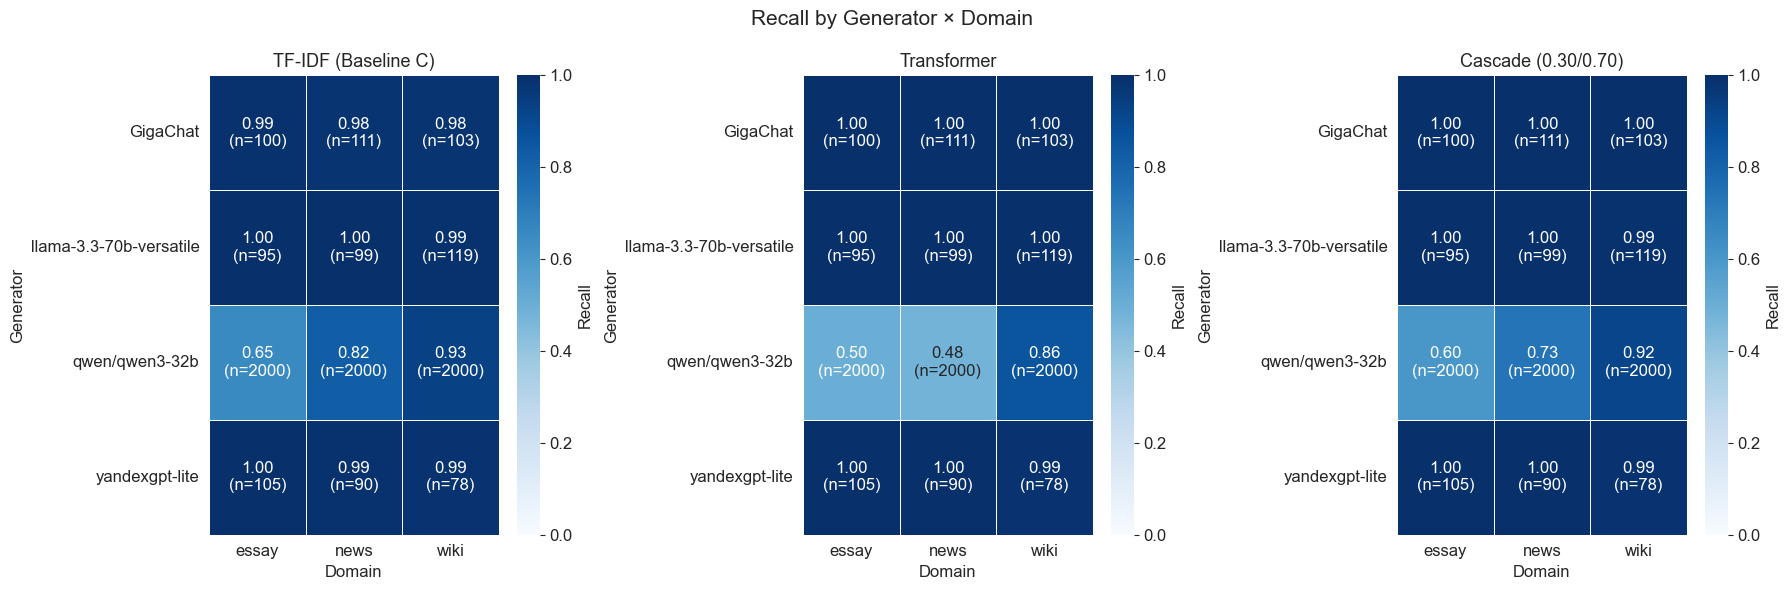

In [10]:
def make_heatmap_data(df, prob_col, threshold=0.5):
    """Строит матрицу recall + n для heatmap."""
    df["pred"] = (df[prob_col] >= threshold).astype(int)
    pivot_recall = df.groupby(["source_model", "domain"])["pred"].mean().unstack(fill_value=0)
    pivot_n = df.groupby(["source_model", "domain"]).size().unstack(fill_value=0)
    return pivot_recall, pivot_n

# Три heatmap: TF-IDF, Transformer, Cascade (0.30/0.70)
df_heat["cascade_prob"] = df_heat["tfidf_prob"].copy()
uncertain = (df_heat["tfidf_prob"] >= 0.30) & (df_heat["tfidf_prob"] <= 0.70)
df_heat.loc[uncertain, "cascade_prob"] = df_heat.loc[uncertain, "trans_prob"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (title, col) in zip(axes, [("TF-IDF (Baseline C)", "tfidf_prob"), 
                                    ("Transformer", "trans_prob"),
                                    ("Cascade (0.30/0.70)", "cascade_prob")]):
    recall, n = make_heatmap_data(df_heat.copy(), col)
    
    # Аннотации: recall (n=XXX)
    annot = recall.copy().astype(str)
    for r in annot.index:
        for c in annot.columns:
            if r in n.index and c in n.columns:
                annot.loc[r, c] = f"{recall.loc[r, c]:.2f}\n(n={int(n.loc[r, c])})"
    
    sns.heatmap(recall, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1,
               ax=ax, cbar_kws={"label": "Recall"}, linewidths=0.5)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("Generator")
    ax.set_xlabel("Domain")

plt.suptitle("Recall by Generator × Domain", fontsize=15)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "artifacts/heatmap_generator_domain.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Adversarial v2: Homoglyph + Back-translation

In [11]:
# 3.1 Гомоглифы — генерация + eval
from generate_adversarial_v2 import apply_homoglyph, load_ai_texts, SPLITS_DIR
import random
random.seed(SEED)

ai_texts_raw = load_ai_texts(SPLITS_DIR / "test_tm.jsonl", max_count=200)
print(f"Source AI texts: {len(ai_texts_raw)}")

# Применяем гомоглифы
homoglyph_texts = [apply_homoglyph(r["text"]) for r in ai_texts_raw]
print(f"Homoglyph texts: {len(homoglyph_texts)}")
print(f"Example: original[:50] = {ai_texts_raw[0]['text'][:50]}")
print(f"         homoglyph[:50] = {homoglyph_texts[0][:50]}")

Source AI texts: 200
Homoglyph texts: 200
Example: original[:50] = Центральный банк решил изменить ключевую ставку – 
         homoglyph[:50] = Центральный банк решил изменить ключевую ставку – 


In [12]:
# Eval гомоглифов через cascade
CASCADE_LO, CASCADE_HI = 0.30, 0.70

def cascade_predict_batch(texts, batch_size=16):
    tfidf_p = tfidf_predict_proba(texts)
    uncertain = (tfidf_p >= CASCADE_LO) & (tfidf_p <= CASCADE_HI)
    final = tfidf_p.copy()
    methods = np.array(["tfidf"] * len(texts))
    if uncertain.sum() > 0:
        unc_texts = [texts[i] for i in np.where(uncertain)[0]]
        trans_p = transformer_predict_proba(unc_texts, batch_size)
        for j, idx in enumerate(np.where(uncertain)[0]):
            final[idx] = trans_p[j]
            methods[idx] = "transformer"
    return final, methods

# Original AI (без гомоглифов) — baseline
orig_texts = [r["text"] for r in ai_texts_raw]
orig_probs, _ = cascade_predict_batch(orig_texts)
orig_recall = (orig_probs >= 0.5).mean()

# Гомоглифы
homo_probs, _ = cascade_predict_batch(homoglyph_texts)
homo_recall = (homo_probs >= 0.5).mean()

print(f"Original AI recall:  {orig_recall:.4f}")
print(f"Homoglyph recall:    {homo_recall:.4f}")
print(f"Drop:                {orig_recall - homo_recall:+.4f}")

Original AI recall:  0.9200
Homoglyph recall:    0.8850
Drop:                +0.0350


In [13]:
# 3.2 Back-translation (если модели установлены)
try:
    from transformers import MarianMTModel, MarianTokenizer
    
    print("Loading Helsinki-NLP/opus-mt-ru-en...")
    ru_en_tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-ru-en")
    ru_en_model = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-ru-en").to(device)
    
    print("Loading Helsinki-NLP/opus-mt-en-ru...")
    en_ru_tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-ru")
    en_ru_model = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-ru").to(device)
    
    HAS_BACKTRANSLATION = True
    print("Back-translation models loaded!")
    
except Exception as e:
    HAS_BACKTRANSLATION = False
    print(f"Back-translation not available: {e}")
    print("Install: pip install sentencepiece")
    print("Models will download automatically on first use (~500MB)")

Loading Helsinki-NLP/opus-mt-ru-en...
Back-translation not available: 
MarianTokenizer requires the SentencePiece library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/google/sentencepiece#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.

Install: pip install sentencepiece
Models will download automatically on first use (~500MB)


In [14]:
if HAS_BACKTRANSLATION:
    from segment_scoring import split_sentences
    
    def back_translate(text, max_sents=30):
        """Ru → En → Ru по предложениям."""
        sents = split_sentences(text)[:max_sents]
        
        # Ru → En
        en_sents = []
        for s in sents:
            inputs = ru_en_tokenizer(s, return_tensors="pt", truncation=True, max_length=512).to(device)
            with torch.no_grad():
                translated = ru_en_model.generate(**inputs, max_length=512)
            en_sents.append(ru_en_tokenizer.decode(translated[0], skip_special_tokens=True))
        
        # En → Ru
        ru_sents = []
        for s in en_sents:
            inputs = en_ru_tokenizer(s, return_tensors="pt", truncation=True, max_length=512).to(device)
            with torch.no_grad():
                translated = en_ru_model.generate(**inputs, max_length=512)
            ru_sents.append(en_ru_tokenizer.decode(translated[0], skip_special_tokens=True))
        
        return " ".join(ru_sents)
    
    # Прогоняем на 200 текстах
    bt_texts = []
    for i, r in enumerate(ai_texts_raw):
        bt = back_translate(r["text"])
        bt_texts.append(bt)
        if (i+1) % 20 == 0:
            print(f"  Back-translated {i+1}/{len(ai_texts_raw)}")
    
    bt_probs, _ = cascade_predict_batch(bt_texts)
    bt_recall = (bt_probs >= 0.5).mean()
    print(f"\nBack-translation recall: {bt_recall:.4f}")
    print(f"Drop from original:      {orig_recall - bt_recall:+.4f}")
else:
    bt_recall = None
    print("Skipping back-translation (models not installed)")

Skipping back-translation (models not installed)


In [15]:
# Сводная таблица adversarial
adv_summary = [
    {"attack": "Original (no attack)", "n": len(orig_texts), "recall": orig_recall},
    {"attack": "Homoglyph (7% chars)", "n": len(homoglyph_texts), "recall": homo_recall},
]
if bt_recall is not None:
    adv_summary.append({"attack": "Back-translation (Ru→En→Ru)", "n": len(bt_texts), "recall": bt_recall})

# Добавляем paraphrase v1 из основных результатов (из test_tm adversarial)
adv_in_test = [r for r in test_tm if "adversarial" in r.get("source_name", "") or r.get("source_model", "") == "adversarial"]
if adv_in_test:
    adv_texts = [r["text"] for r in adv_in_test]
    adv_probs, _ = cascade_predict_batch(adv_texts)
    adv_summary.append({"attack": "Paraphrase v1 (LLM rewrite)", "n": len(adv_texts), "recall": (adv_probs >= 0.5).mean()})

df_adv = pd.DataFrame(adv_summary)
print("\n=== Adversarial Robustness ===")
print(df_adv.to_string(index=False))


=== Adversarial Robustness ===
                     attack   n   recall
       Original (no attack) 200 0.920000
       Homoglyph (7% chars) 200 0.885000
Paraphrase v1 (LLM rewrite) 511 0.784736


---
## 4. Segment-level Scoring PoC

In [16]:
from segment_scoring import score_segments, summarize_segments

predict_fn = lambda t: tfidf_predict_proba([t])[0]

# Подбираем примеры
# Full human
human_texts_tm = [r["text"] for r in test_tm if (r["label"] == 0 or r["label"] == "human")]
# Full AI (не adversarial)
ai_texts_tm = [r["text"] for r in test_tm if (r["label"] == 1 or r["label"] == "ai") and "adversarial" not in r.get("source_name", "") and r.get("source_model", "") != "adversarial"]
# Mixed (из edited_ai)
mixed_texts = [r["text"] for r in edited_data.get("mixed", [])]
# Replace_50 
r50_texts = [r["text"] for r in edited_data.get("replace_50", [])]

print(f"Human: {len(human_texts_tm)}, AI: {len(ai_texts_tm)}, Mixed: {len(mixed_texts)}, Replace_50: {len(r50_texts)}")

Human: 900, AI: 900, Mixed: 150, Replace_50: 100


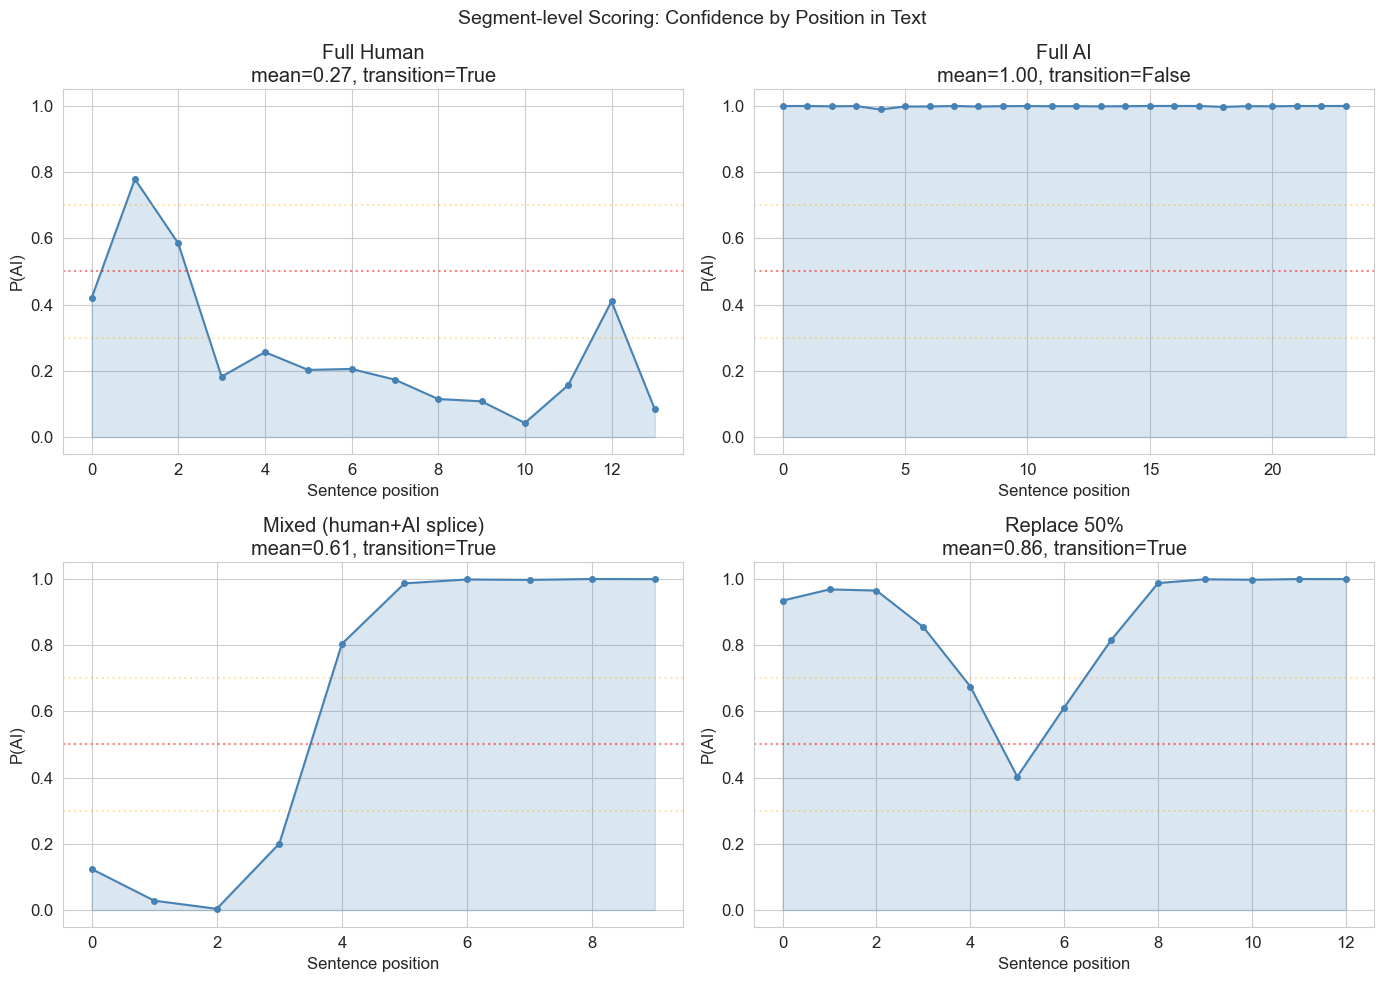

In [17]:
# Выбираем по одному длинному тексту для визуализации
# (>1500 символов, чтобы было достаточно окон)

def pick_long_text(texts, min_len=1500):
    candidates = [t for t in texts if len(t) >= min_len]
    if candidates:
        return candidates[0]
    return texts[0] if texts else ""

examples = {
    "Full Human": pick_long_text(human_texts_tm),
    "Full AI": pick_long_text(ai_texts_tm),
    "Mixed (human+AI splice)": pick_long_text(mixed_texts),
    "Replace 50%": pick_long_text(r50_texts),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (title, text) in zip(axes.flat, examples.items()):
    scores = score_segments(text, predict_fn, window_size=3, step=1, max_windows=40)
    
    if not scores:
        ax.set_title(f"{title}\n(too short)")
        continue
    
    positions = [s.start_sent for s in scores]
    probs = [s.prob_ai for s in scores]
    summary = summarize_segments(scores)
    
    ax.plot(positions, probs, "o-", markersize=4, linewidth=1.5, color="steelblue")
    ax.fill_between(positions, probs, alpha=0.2, color="steelblue")
    ax.axhline(0.5, color="red", linestyle=":", alpha=0.5)
    ax.axhline(0.3, color="orange", linestyle=":", alpha=0.3)
    ax.axhline(0.7, color="orange", linestyle=":", alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Sentence position")
    ax.set_ylabel("P(AI)")
    ax.set_title(f"{title}\nmean={summary['mean_prob']:.2f}, transition={summary['transition_detected']}")

plt.suptitle("Segment-level Scoring: Confidence by Position in Text", fontsize=14)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "artifacts/segment_scoring_poc.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Две кривые деградации: TF-IDF vs Transformer

In [18]:
# Прогоняем Transformer на всех edited AI текстах
orig_map = {r["doc_id"]: r["text"] for r in test_tm if r.get("label") == 1 or r.get("label") == "ai"}

degrad_records = []

for level, rows in sorted(edited_data.items()):
    texts = [r["text"] for r in rows]
    print(f"{level}: {len(texts)} texts → inference...")
    
    tfidf_p = tfidf_predict_proba(texts)
    trans_p = transformer_predict_proba(texts)
    
    for i, r in enumerate(rows):
        if "edit_ratio" in r.get("meta", {}):
            ratio = r["meta"]["edit_ratio"]
        else:
            orig_text = orig_map.get(r["meta"]["original_doc_id"], "")
            ratio = SequenceMatcher(None, orig_text, r["text"]).ratio() if orig_text else None
        
        degrad_records.append({
            "level": level,
            "edit_ratio": ratio,
            "tfidf_prob": tfidf_p[i],
            "trans_prob": trans_p[i],
            "domain": r.get("domain", ""),
        })

df_deg = pd.DataFrame(degrad_records)
print(f"\nTotal: {len(df_deg)} records")

heavy_edit: 150 texts → inference...
light_edit: 150 texts → inference...
mixed: 150 texts → inference...
replace_10: 100 texts → inference...
replace_30: 100 texts → inference...
replace_50: 100 texts → inference...

Total: 750 records


In [19]:
# Сводная таблица: TF-IDF vs Transformer по уровням
deg_summary = df_deg.groupby("level").agg(
    n=("edit_ratio", "count"),
    median_ratio=("edit_ratio", "median"),
    tfidf_recall=("tfidf_prob", lambda x: (x >= 0.5).mean()),
    tfidf_median=("tfidf_prob", "median"),
    trans_recall=("trans_prob", lambda x: (x >= 0.5).mean()),
    trans_median=("trans_prob", "median"),
).sort_values("median_ratio", ascending=False).round(3)

print("=== TF-IDF vs Transformer on Edited AI ===")
print(deg_summary.to_string())

=== TF-IDF vs Transformer on Edited AI ===
              n  median_ratio  tfidf_recall  tfidf_median  trans_recall  trans_median
level                                                                                
light_edit  150         0.982         0.880         0.998         0.987         1.000
replace_10  100         0.927         0.910         0.998         0.980         1.000
replace_30  100         0.729         0.910         0.997         0.980         1.000
replace_50  100         0.536         0.950         0.997         1.000         1.000
mixed       150         0.363         0.427         0.438         0.487         0.129
heavy_edit  150         0.199         1.000         1.000         1.000         1.000


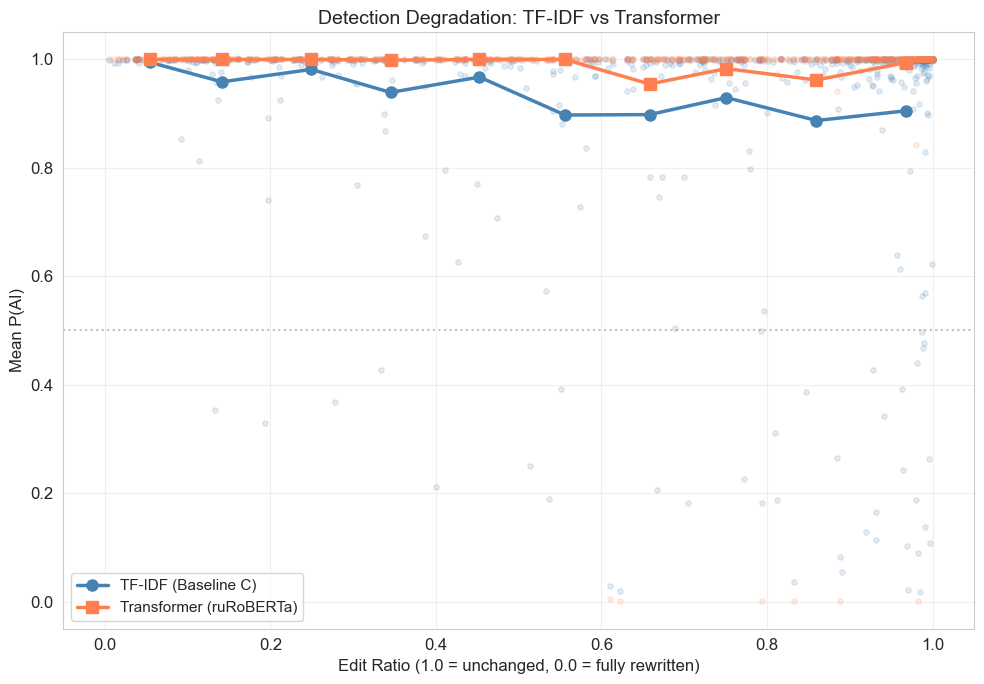

In [20]:
# Две кривые деградации на одном графике
fig, ax = plt.subplots(figsize=(10, 7))

# Без mixed (он на другой шкале)
df_nomix = df_deg[df_deg["level"] != "mixed"].dropna(subset=["edit_ratio"])

ax.scatter(df_nomix["edit_ratio"], df_nomix["tfidf_prob"], alpha=0.15, s=15, color="steelblue", label="_nolegend_")
ax.scatter(df_nomix["edit_ratio"], df_nomix["trans_prob"], alpha=0.15, s=15, color="coral", label="_nolegend_")

# Средние по бинам
bins = np.linspace(0, 1, 11)
df_nomix["ratio_bin"] = pd.cut(df_nomix["edit_ratio"], bins)
binned = df_nomix.groupby("ratio_bin", observed=True).agg(
    ratio_mid=("edit_ratio", "mean"),
    tfidf_mean=("tfidf_prob", "mean"),
    trans_mean=("trans_prob", "mean"),
    n=("edit_ratio", "count"),
).dropna()

ax.plot(binned["ratio_mid"], binned["tfidf_mean"], "o-", color="steelblue", 
        linewidth=2.5, markersize=8, label="TF-IDF (Baseline C)")
ax.plot(binned["ratio_mid"], binned["trans_mean"], "s-", color="coral",
        linewidth=2.5, markersize=8, label="Transformer (ruRoBERTa)")

ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Edit Ratio (1.0 = unchanged, 0.0 = fully rewritten)", fontsize=12)
ax.set_ylabel("Mean P(AI)", fontsize=12)
ax.set_title("Detection Degradation: TF-IDF vs Transformer", fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "artifacts/degradation_tfidf_vs_transformer.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Сохранение результатов

In [21]:
df_ablation.to_csv(PROJECT_ROOT / "artifacts/threshold_ablation.csv", index=False)
df_adv.to_csv(PROJECT_ROOT / "artifacts/adversarial_v2_summary.csv", index=False)
deg_summary.to_csv(PROJECT_ROOT / "artifacts/degradation_tfidf_vs_transformer.csv")

print("Saved:")
print("  artifacts/threshold_ablation.csv")
print("  artifacts/threshold_ablation.png")
print("  artifacts/heatmap_generator_domain.png")
print("  artifacts/adversarial_v2_summary.csv")
print("  artifacts/segment_scoring_poc.png")
print("  artifacts/degradation_tfidf_vs_transformer.csv")
print("  artifacts/degradation_tfidf_vs_transformer.png")

Saved:
  artifacts/threshold_ablation.csv
  artifacts/threshold_ablation.png
  artifacts/heatmap_generator_domain.png
  artifacts/adversarial_v2_summary.csv
  artifacts/segment_scoring_poc.png
  artifacts/degradation_tfidf_vs_transformer.csv
  artifacts/degradation_tfidf_vs_transformer.png
